# Breast Cancer Logistic Regression Analysis
This notebook performs:
- Data exploration
- Preprocessing
- Train-test split
- Model training
- ROC curve plotting and AUC calculation

## Imports and Dataset Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

data = load_breast_cancer()
X = data.data
y = data.target

## Explore Dataset

In [2]:
print("Keys in dataset:", data.keys())
print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nTarget names:", data.target_names)

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
print("\nFirst 5 rows:")
df.head()

Keys in dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Number of samples: 569
Number of features: 30

Target names: ['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Scaling and train-test split

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

## Model Training and Predictions

In [4]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

## Threshold wise confusion matrices

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)
    TN, FP, FN, TP = cm.ravel()
    TPR_val = TP / (TP + FN) if (TP + FN) != 0 else 0
    FPR_val = FP / (FP + TN) if (FP + TN) != 0 else 0

    print(f"Threshold: {th}")
    print("Confusion Matrix:\n", cm)
    print("TPR:", TPR_val)
    print("FPR:", FPR_val)
    print("-"*40)

Threshold: inf
Confusion Matrix:
 [[ 63   0]
 [108   0]]
TPR: 0.0
FPR: 0.0
----------------------------------------
Threshold: 0.9999998901305972
Confusion Matrix:
 [[ 63   0]
 [107   1]]
TPR: 0.009259259259259259
FPR: 0.0
----------------------------------------
Threshold: 0.9264438518626266
Confusion Matrix:
 [[63  0]
 [11 97]]
TPR: 0.8981481481481481
FPR: 0.0
----------------------------------------
Threshold: 0.9257222579563398
Confusion Matrix:
 [[62  1]
 [11 97]]
TPR: 0.8981481481481481
FPR: 0.015873015873015872
----------------------------------------
Threshold: 0.4845399735270887
Confusion Matrix:
 [[ 62   1]
 [  1 107]]
TPR: 0.9907407407407407
FPR: 0.015873015873015872
----------------------------------------
Threshold: 0.37731215453553774
Confusion Matrix:
 [[ 60   3]
 [  1 107]]
TPR: 0.9907407407407407
FPR: 0.047619047619047616
----------------------------------------
Threshold: 0.2357519094304118
Confusion Matrix:
 [[ 60   3]
 [  0 108]]
TPR: 1.0
FPR: 0.047619047619047616
-

## Segment wise AUC and Overall AUC

In [6]:
segment_auc = [(fpr[i+1]-fpr[i])*(tpr[i]+tpr[i+1])/2 for i in range(len(fpr)-1)]

print("Segment-wise AUC values:")
for i, val in enumerate(segment_auc):
    print(f"Segment {i+1}: {val}")

total_auc = roc_auc_score(y_test, y_prob)
print("\nOverall AUC:", total_auc)

if np.isclose(total_auc, 0.5, atol=0.01):
    print("Random classifier (AUC ~ 0.5)")
elif np.isclose(total_auc, 1.0, atol=1e-6):
    print("Perfect classifier (AUC = 1)")
else:
    print("Good classifier (AUC > 0.5)")

Segment-wise AUC values:
Segment 1: 0.0
Segment 2: 0.0
Segment 3: 0.014256319811875367
Segment 4: 0.0
Segment 5: 0.03145208700764256
Segment 6: 0.0
Segment 7: 0.9523809523809523

Overall AUC: 0.9980893592004703
Good classifier (AUC > 0.5)


## ROC Curve Plot

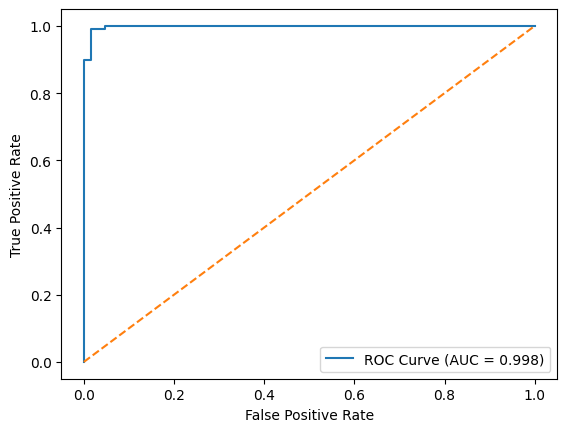

In [7]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {total_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()